## 1. Environment Setup & Data Loading
Mount Google Drive and securely load datasets.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import os

final_file = "/content/drive/MyDrive/cicids2018_final_train.csv"

# delete old file if exists
if os.path.exists(final_file):
    os.remove(final_file)

csv_files = glob.glob("/content/drive/MyDrive/cicids2018/*.csv")
print("Total files:", len(csv_files))

header_written = False

for f in csv_files:
    print("Sampling from:", f)

    for chunk in pd.read_csv(
        f,
        chunksize=50_000,   # VERY SAFE
        engine="python",
        on_bad_lines="skip"
    ):
        # clean
        chunk.replace([float("inf"), -float("inf")], pd.NA, inplace=True)
        chunk.dropna(inplace=True)

        # take only 5% sample
        sample = chunk.sample(frac=0.05, random_state=42)

        sample.to_csv(
            final_file,
            mode="a",
            index=False,
            header=not header_written
        )
        header_written = True

print("FINAL TRAINING DATASET CREATED SAFELY")


Total files: 10
Sampling from: /content/drive/MyDrive/cicids2018/02-14-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-15-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-16-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-20-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-21-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-22-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-23-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/02-28-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/03-01-2018.csv
Sampling from: /content/drive/MyDrive/cicids2018/03-02-2018.csv
FINAL TRAINING DATASET CREATED SAFELY


## 2. Data Preprocessing & Cleaning
Handle missing values, encode labels, and prepare data shapes.


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/cicids2018_final_train.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset loaded successfully")
df.shape


Dataset loaded successfully


(412527, 80)

In [ ]:
df.to_csv(
    "/content/drive/MyDrive/cicids2018_final_train_clean.csv",
    index=False
)


In [ ]:
df.head()


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,21,6,14/02/2018 10:50:14,2,1,1,0,0,0,0,...,40,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce
1,21,6,14/02/2018 10:38:07,2,1,1,0,0,0,0,...,40,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce
2,21,6,14/02/2018 10:33:29,1,1,1,0,0,0,0,...,40,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce
3,21,6,14/02/2018 10:39:38,30,1,1,0,0,0,0,...,40,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce
4,21,6,14/02/2018 10:53:12,1,1,1,0,0,0,0,...,40,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412527 entries, 0 to 412526
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Dst Port           412527 non-null  object
 1   Protocol           412527 non-null  object
 2   Timestamp          412527 non-null  object
 3   Flow Duration      412527 non-null  object
 4   Tot Fwd Pkts       412527 non-null  object
 5   Tot Bwd Pkts       412527 non-null  object
 6   TotLen Fwd Pkts    412527 non-null  object
 7   TotLen Bwd Pkts    412527 non-null  object
 8   Fwd Pkt Len Max    412527 non-null  object
 9   Fwd Pkt Len Min    412527 non-null  object
 10  Fwd Pkt Len Mean   412527 non-null  object
 11  Fwd Pkt Len Std    412527 non-null  object
 12  Bwd Pkt Len Max    412527 non-null  object
 13  Bwd Pkt Len Min    412527 non-null  object
 14  Bwd Pkt Len Mean   412527 non-null  object
 15  Bwd Pkt Len Std    412527 non-null  object
 16  Flow Byts/s        4

In [ ]:
df["Label"].value_counts()


,count
Label,
Benign,304007
DDOS attack-HOIC,34276
DoS attacks-Hulk,23035
Bot,14315
FTP-BruteForce,9726
SSH-Bruteforce,9342
Infilteration,8052
DoS attacks-SlowHTTPTest,7013
DoS attacks-GoldenEye,2058


In [ ]:
df["Label"] = df["Label"].apply(lambda x: 0 if x == "Benign" else 1)
df["Label"].value_counts()


,count
Label,
0,304007
1,108520


## 3. Baseline Models
Train preliminary Logistic Regression, Random Forest, and SVM models for performance context.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/drive/MyDrive/cicids2018_final_train_clean.csv",
    engine="python"
)

df["Label"] = df["Label"].apply(lambda x: 0 if x == "Benign" else 1)

X = df.drop("Label", axis=1)
y = df["Label"]


In [ ]:
X = X.apply(pd.to_numeric, errors="coerce")


In [ ]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Timestamp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
X_imputed.shape


(412527, 78)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Scaling completed successfully")


✅ Scaling completed successfully


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


Logistic Regression
Accuracy: 0.7577630717765981
Precision: 0.5367691122335416
Recall: 0.5777736822705493
F1 Score: 0.5565171082412462


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",  # IMPORTANT
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))


Random Forest Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     60802
           1       0.97      0.93      0.95     21704

    accuracy                           0.98     82506
   macro avg       0.98      0.96      0.97     82506
weighted avg       0.98      0.98      0.98     82506



In [ ]:
import joblib

joblib.dump(rf, "/content/drive/MyDrive/random_forest_ids_model.pkl")
print("Random Forest model saved")


Random Forest model saved


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/drive/MyDrive/cicids2018_final_train_clean.csv",
    engine="python"
)

df["Label"] = df["Label"].apply(lambda x: 0 if x == "Benign" else 1)

print(df.shape)


(412527, 80)


In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]


In [ ]:
from sklearn.impute import SimpleImputer

X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

print(X_imputed.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Timestamp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


(412527, 78)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(330021, 78) (82506, 78)


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Scaling completed successfully")


✅ Scaling completed successfully


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("Linear SVM Report")
print(classification_report(y_test, y_pred_svm))


Linear SVM Report
              precision    recall  f1-score   support

           0       0.87      0.80      0.84     60802
           1       0.55      0.67      0.60     21704

    accuracy                           0.77     82506
   macro avg       0.71      0.74      0.72     82506
weighted avg       0.79      0.77      0.77     82506



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

final_results


,Model,Accuracy,F1 Score
0,Logistic Regression,0.757763,0.556517
1,Random Forest,0.975796,0.953008
2,Linear SVM,0.766853,0.602085


In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]


In [ ]:
from sklearn.impute import SimpleImputer

X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

print("After imputation:", X_imputed.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Timestamp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


After imputation: (412527, 78)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(330021, 78) (82506, 78)


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully")


Scaling completed successfully


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000
)


In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("svm", svm)
    ],
    voting="hard"
)


In [ ]:
ensemble_model.fit(X_train_scaled, y_train)
print("Ensemble model trained successfully")


Ensemble model trained successfully


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_pred_ensemble = ensemble_model.predict(X_test_scaled)

print("Ensemble Classification Report")
print(classification_report(y_test, y_pred_ensemble))

print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("F1 Score:", f1_score(y_test, y_pred_ensemble))


Ensemble Classification Report
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     60802
           1       0.60      0.84      0.70     21704

    accuracy                           0.81     82506
   macro avg       0.77      0.82      0.78     82506
weighted avg       0.85      0.81      0.82     82506

Accuracy: 0.8115894601604732
F1 Score: 0.7000019298685759


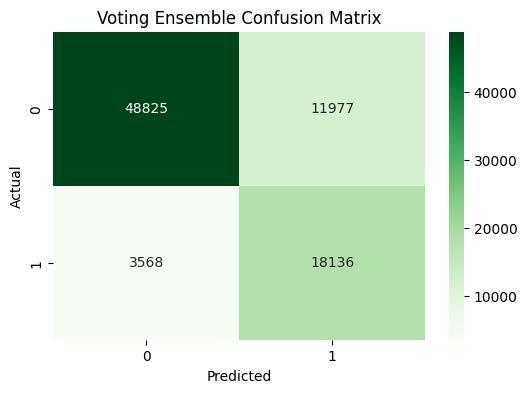

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ensemble)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Ensemble Confusion Matrix")
plt.show()


In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble_weighted = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("svm", svm)
    ],
    voting="hard",
    weights=[1, 3, 2]   # RF strongest
)


In [ ]:
ensemble_weighted.fit(X_train_scaled, y_train)

y_pred_ensemble_w = ensemble_weighted.predict(X_test_scaled)

from sklearn.metrics import classification_report, accuracy_score, f1_score

print("Weighted Ensemble Report")
print(classification_report(y_test, y_pred_ensemble_w))

print("Accuracy:", accuracy_score(y_test, y_pred_ensemble_w))
print("F1 Score:", f1_score(y_test, y_pred_ensemble_w))


Weighted Ensemble Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     60802
           1       0.99      0.82      0.89     21704

    accuracy                           0.95     82506
   macro avg       0.96      0.91      0.93     82506
weighted avg       0.95      0.95      0.95     82506

Accuracy: 0.9481734661721571
F1 Score: 0.8922107385933955


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
cm = confusion_matrix(y_test, y_pred_ensemble_w)


Text(0.5, 1.0, 'Weighted Ensemble Confusion Matrix')

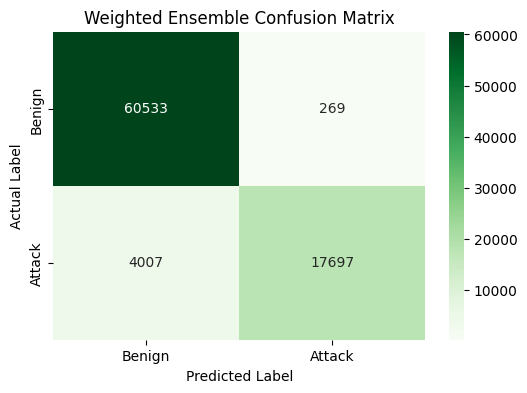

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Weighted Ensemble Confusion Matrix")


In [ ]:
plt.savefig(
    "/content/drive/MyDrive/confusion_matrix_weighted_ensemble.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.show()
plt.close()


## 4. Feature Selection & Top-K Experiments
Perform XGBoost feature importance ranking and evaluate k-feature subsets.


In [ ]:
BASE_PATH = "/content/drive/MyDrive/IDS_Research_Results"

os.makedirs(BASE_PATH, exist_ok=True)
os.makedirs(f"{BASE_PATH}/tables", exist_ok=True)
os.makedirs(f"{BASE_PATH}/models", exist_ok=True)
os.makedirs(f"{BASE_PATH}/features", exist_ok=True)
os.makedirs(f"{BASE_PATH}/metadata", exist_ok=True)

print("Result directories ready")


Result directories ready


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/cicids2018_final_train_clean.csv",
    engine="python"
)

df["Label"] = df["Label"].apply(lambda x: 0 if x == "Benign" else 1)

X = df.drop("Label", axis=1)
y = df["Label"]

print("Dataset loaded:", X.shape)


Dataset loaded: (412527, 79)


In [ ]:
from sklearn.impute import SimpleImputer

X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

feature_names = np.array(X.columns)

print("Data cleaned and imputed")


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Timestamp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Data cleaned and imputed


In [ ]:
from xgboost import XGBClassifier

xgb_fs = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)

xgb_fs.fit(X_imputed, y)

importances = xgb_fs.feature_importances_
ranking = np.argsort(importances)[::-1]

top_features = {
    10: ranking[:10],
    20: ranking[:20],
    30: ranking[:30]
}

print("Feature ranking completed")


Feature ranking completed


In [ ]:
for k, idx in top_features.items():
    selected = feature_names[idx]
    pd.DataFrame({"Selected_Features": selected}).to_csv(
        f"{BASE_PATH}/features/top_{k}_features.csv",
        index=False
    )

print("Top‑10 / 20 / 30 features saved")


Top‑10 / 20 / 30 features saved


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("10‑Fold CV ready")


10‑Fold CV ready


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "LinearSVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42
    )
}

print("Models initialized")


Models initialized


In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model_cv(model, X, y, cv):
    acc_scores, f1_scores = [], []

    for train_idx, test_idx in cv.split(X, y):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

        scaler = RobustScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)

        acc_scores.append(accuracy_score(yte, y_pred))
        f1_scores.append(f1_score(yte, y_pred))

    return np.mean(acc_scores), np.mean(f1_scores)


In [ ]:
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    X_imputed,
    y,
    train_size=0.3,        # 30% data
    stratify=y,
    random_state=42
)

print("Subsample shape:", X_small.shape)


Subsample shape: (123758, 78)


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=-1,
        eval_metric="logloss",
        random_state=42
    )
}


In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def evaluate_model_cv(model, X, y, cv):
    acc_scores, f1_scores = [], []

    for train_idx, test_idx in cv.split(X, y):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

        scaler = RobustScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)

        acc_scores.append(accuracy_score(yte, y_pred))
        f1_scores.append(f1_score(yte, y_pred))

    return np.mean(acc_scores), np.mean(f1_scores)


In [ ]:
results = []

for k, idx in top_features.items():
    Xk = X_small[:, idx]

    for model_name, model in models.items():
        acc, f1 = evaluate_model_cv(model, Xk, y_small, cv)

        results.append({
            "Model": model_name,
            "Num_Features": k,
            "CV_Accuracy": acc,
            "CV_F1": f1
        })

results_df = pd.DataFrame(results)
results_df


,Model,Num_Features,CV_Accuracy,CV_F1
0,RandomForest,10,0.973981,0.949784
1,XGBoost,10,0.980147,0.960905
2,RandomForest,20,0.976333,0.954060
3,XGBoost,20,0.980219,0.961080
4,RandomForest,30,0.976866,0.955003
5,XGBoost,30,0.980260,0.961166


In [ ]:
results_df.to_csv(
    f"{BASE_PATH}/tables/cv_results_fast_mode.csv",
    index=False
)

results_df


,Model,Num_Features,CV_Accuracy,CV_F1
0,RandomForest,10,0.973981,0.949784
1,XGBoost,10,0.980147,0.960905
2,RandomForest,20,0.976333,0.954060
3,XGBoost,20,0.980219,0.961080
4,RandomForest,30,0.976866,0.955003
5,XGBoost,30,0.980260,0.961166


In [ ]:
best_k = (
    results_df
    .groupby("Num_Features")["CV_F1"]
    .mean()
    .idxmax()
)

best_k


np.int64(30)

## 5. Final Ensemble Model Training & Evaluation
Build the final weighted ensemble (Random Forest + XGBoost) pipeline and display final benchmark comparisons.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Linear SVM",
        "Weighted Voting Ensemble"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_ensemble_w)
    ],
    "Precision (Attack)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_ensemble_w)
    ],
    "Recall (Attack)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_ensemble_w)
    ],
    "F1 Score (Attack)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_ensemble_w)
    ]
})

final_comparison


,Model,Accuracy,Precision (Attack),Recall (Attack),F1 Score (Attack)
0,Logistic Regression,0.759327,0.532127,0.704755,0.606395
1,Random Forest,0.975796,0.973885,0.933008,0.953008
2,Linear SVM,0.766853,0.546325,0.670522,0.602085
3,Weighted Voting Ensemble,0.948173,0.985027,0.815380,0.892211


In [ ]:
best_idx = top_features[best_k]

X_final = X_imputed[:, best_idx]

print("Final feature matrix shape:", X_final.shape)


Final feature matrix shape: (412527, 30)


In [ ]:
from sklearn.preprocessing import RobustScaler

final_scaler = RobustScaler()
X_final_scaled = final_scaler.fit_transform(X_final)

print("Scaling completed")


Scaling completed


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

rf_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    eval_metric="logloss",
    random_state=42
)

svm_final = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000
)

print("Final models initialized")


Final models initialized


In [ ]:
rf_final.fit(X_final, y)
xgb_final.fit(X_final, y)
svm_final.fit(X_final_scaled, y)

print("RF, XGBoost, and Linear SVM trained on full data")


RF, XGBoost, and Linear SVM trained on full data


In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble_final = VotingClassifier(
    estimators=[
        ("rf", rf_final),
        ("xgb", xgb_final),
        ("svm", svm_final)
    ],
    voting="hard",
    weights=[3, 4, 2]   # XGBoost strongest
)

ensemble_final.fit(X_final_scaled, y)

print("Weighted ensemble trained on full data")


Weighted ensemble trained on full data


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

Xtr, Xte, ytr, yte = train_test_split(
    X_final_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

ensemble_final.fit(Xtr, ytr)
y_pred = ensemble_final.predict(Xte)

print("Accuracy:", accuracy_score(yte, y_pred))
print("F1:", f1_score(yte, y_pred))


Accuracy: 0.979080309310838
F1: 0.9590432347776565


In [ ]:
import joblib

# Save ensemble
joblib.dump(
    ensemble_final,
    f"{BASE_PATH}/models/final_weighted_ensemble_full.pkl"
)

# Save scaler
joblib.dump(
    final_scaler,
    f"{BASE_PATH}/models/final_scaler_full.pkl"
)

# Save chosen feature list
import pandas as pd
pd.DataFrame({
    "Selected_Features": feature_names[best_idx]
}).to_csv(
    f"{BASE_PATH}/features/final_selected_features_k{best_k}.csv",
    index=False
)

print("Final models, scaler, and features saved")


Final models, scaler, and features saved


In [ ]:
final_summary = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Linear SVM", "Weighted Ensemble"],
    "Feature_Count": [best_k]*4
})

final_summary.to_csv(
    f"{BASE_PATH}/tables/final_models_trained_summary.csv",
    index=False
)

final_summary


,Model,Feature_Count
0,Random Forest,30
1,XGBoost,30
2,Linear SVM,30
3,Weighted Ensemble,30


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("10‑Fold CV ready")


10‑Fold CV ready


In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def evaluate_ensemble_cv(model, X, y, cv):
    acc, prec, rec, f1 = [], [], [], []

    for train_idx, test_idx in cv.split(X, y):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

        scaler = RobustScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)

        acc.append(accuracy_score(yte, y_pred))
        prec.append(precision_score(yte, y_pred))
        rec.append(recall_score(yte, y_pred))
        f1.append(f1_score(yte, y_pred))

    return {
        "Accuracy_Mean": np.mean(acc),
        "Accuracy_STD": np.std(acc),
        "Precision_Mean": np.mean(prec),
        "Recall_Mean": np.mean(rec),
        "F1_Mean": np.mean(f1),
        "F1_STD": np.std(f1)
    }



In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble_cv_fast = VotingClassifier(
    estimators=[
        ("rf", rf_final),
        ("xgb", xgb_final)
    ],
    voting="hard",
    weights=[3, 4]   # XGBoost slightly stronger
)

print("Fast CV ensemble ready")


Fast CV ensemble ready


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

acc, prec, rec, f1 = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(cv10.split(X_final, y), 1):
    print(f"Running fold {fold}/10")

    Xtr, Xte = X_final[train_idx], X_final[test_idx]
    ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

    scaler = RobustScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    ensemble_cv_fast.fit(Xtr, ytr)
    y_pred = ensemble_cv_fast.predict(Xte)

    acc.append(accuracy_score(yte, y_pred))
    prec.append(precision_score(yte, y_pred))
    rec.append(recall_score(yte, y_pred))
    f1.append(f1_score(yte, y_pred))

final_cv_results = {
    "Model": "Weighted Ensemble (RF + XGBoost)",
    "Num_Features": best_k,
    "Accuracy_Mean": np.mean(acc),
    "Accuracy_STD": np.std(acc),
    "Precision_Mean": np.mean(prec),
    "Recall_Mean": np.mean(rec),
    "F1_Mean": np.mean(f1),
    "F1_STD": np.std(f1)
}

final_cv_results


Running fold 1/10
Running fold 2/10
Running fold 3/10
Running fold 4/10
Running fold 5/10
Running fold 6/10
Running fold 7/10
Running fold 8/10
Running fold 9/10
Running fold 10/10


{'Model': 'Weighted Ensemble (RF + XGBoost)',
 'Num_Features': np.int64(30),
 'Accuracy_Mean': np.float64(0.980386735340909),
 'Accuracy_STD': np.float64(0.00069824477078502),
 'Precision_Mean': np.float64(0.9949943005302749),
 'Recall_Mean': np.float64(0.9301234795429414),
 'F1_Mean': np.float64(0.96146312158382),
 'F1_STD': np.float64(0.0014238090256559035)}

In [ ]:
import pandas as pd

final_cv_df = pd.DataFrame([final_cv_results])

final_cv_df.to_csv(
    f"{BASE_PATH}/tables/final_10fold_cv_ensemble_fast.csv",
    index=False
)

final_cv_df


,Model,Num_Features,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,F1_STD
0,Weighted Ensemble (RF + XGBoost),30,0.980387,0.000698,0.994994,0.930123,0.961463,0.001424


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

import seaborn as sns
sns.set_theme(style="whitegrid")



In [ ]:
feat_df = pd.read_csv(
    "/content/drive/MyDrive/IDS_Research_Results/features/final_selected_features_k30.csv"
)

print(feat_df.head())
print(feat_df.columns)


   Selected_Features
0   Fwd Seg Size Avg
1    Bwd Pkt Len Min
2  Fwd Act Data Pkts
3       FIN Flag Cnt
4       Tot Bwd Pkts
Index(['Selected_Features'], dtype='object')


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/IDS_Research_Results"

print(os.listdir(BASE_PATH))


['tables', 'models', 'features', 'metadata', 'figures']


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/drive/MyDrive/cicids2018_final_train_clean.csv",
    low_memory=False
)

# Encode label
df["Label"] = df["Label"].apply(lambda x: 0 if x == "Benign" else 1)

X = df.drop(columns=["Label"])
y = df["Label"].values

print("Dataset loaded:", X.shape)


Dataset loaded: (412527, 79)


In [ ]:
feat_df = pd.read_csv(
    f"{BASE_PATH}/features/final_selected_features_k30.csv"
)

selected_features = feat_df["Selected_Features"].tolist()

X_final = X[selected_features]

print("Selected feature matrix:", X_final.shape)


Selected feature matrix: (412527, 30)


In [ ]:
# Convert to numeric
X_final = X_final.apply(pd.to_numeric, errors="coerce")

# Replace infinities
X_final.replace([np.inf, -np.inf], np.nan, inplace=True)

# Median imputation
X_final.fillna(X_final.median(), inplace=True)


In [ ]:
import joblib

scaler = joblib.load(
    f"{BASE_PATH}/models/final_scaler_full.pkl"
)

ensemble = joblib.load(
    f"{BASE_PATH}/models/final_weighted_ensemble_full.pkl"
)

print("Model and scaler loaded successfully.")


/usr/lib/python3.12/pickle.py:1760: UserWarning: [06:59:45] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Model and scaler loaded successfully.


In [ ]:
import pandas as pd

cv_final = pd.read_csv(
    "/content/drive/MyDrive/IDS_Research_Results/tables/final_10fold_cv_ensemble_fast.csv"
)

cv_final


,Model,Num_Features,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,F1_STD
0,Weighted Ensemble (RF + XGBoost),30,0.980387,0.000698,0.994994,0.930123,0.961463,0.001424


In [ ]:
BASE_PATH = "/content/drive/MyDrive/IDS_Research_Results"


In [ ]:
import pandas as pd

cv_final = pd.read_csv(
    f"{BASE_PATH}/tables/final_10fold_cv_ensemble_fast.csv"
)

print("File loaded successfully")
cv_final.head()


File loaded successfully


,Model,Num_Features,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,F1_STD
0,Weighted Ensemble (RF + XGBoost),30,0.980387,0.000698,0.994994,0.930123,0.961463,0.001424


In [ ]:
cv_final[['Accuracy_Mean','Precision_Mean','Recall_Mean','F1_Mean']]

,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean
0,0.980387,0.994994,0.930123,0.961463


In [ ]:
final_metrics = cv_final[[
    'Accuracy_Mean',
    'Accuracy_STD',
    'Precision_Mean',
    'Recall_Mean',
    'F1_Mean',
    'F1_STD'
]].round(4)

final_metrics


,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,F1_STD
0,0.9804,0.0007,0.995,0.9301,0.9615,0.0014


In [ ]:
row = cv_final.iloc[0]

formatted_results = {
    "Accuracy": f"{row['Accuracy_Mean']:.4f} ± {row['Accuracy_STD']:.4f}",
    "Precision": f"{row['Precision_Mean']:.4f}",
    "Recall": f"{row['Recall_Mean']:.4f}",
    "F1-Score": f"{row['F1_Mean']:.4f} ± {row['F1_STD']:.4f}"
}

formatted_results


{'Accuracy': '0.9804 ± 0.0007',
 'Precision': '0.9950',
 'Recall': '0.9301',
 'F1-Score': '0.9615 ± 0.0014'}

In [ ]:
import pandas as pd

features_df = pd.read_csv(
    f"{BASE_PATH}/features/final_selected_features_k30.csv"
)

print(features_df.head())
print(features_df.columns)


   Selected_Features
0   Fwd Seg Size Avg
1    Bwd Pkt Len Min
2  Fwd Act Data Pkts
3       FIN Flag Cnt
4       Tot Bwd Pkts
Index(['Selected_Features'], dtype='object')


In [ ]:
selected_features = features_df.iloc[:, 0].tolist()

print("Number of selected features:", len(selected_features))


Number of selected features: 30


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score


In [ ]:
BASE_PATH = "/content/drive/MyDrive/IDS_Research_Results"


In [ ]:
features_df = pd.read_csv(
    f"{BASE_PATH}/features/final_selected_features_k30.csv"
)

selected_features = features_df.iloc[:, 0].tolist()

print("Original number of selected features:", len(selected_features))


Original number of selected features: 30


In [ ]:
selected_features = [f for f in selected_features if f != "Timestamp"]

print("After removing Timestamp:", len(selected_features))


After removing Timestamp: 29


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/cicids2018_final_train_clean.csv",
    low_memory=False
)

df["Label"] = df["Label"].apply(lambda x: 0 if x == "Benign" else 1)


In [ ]:
X = df[selected_features].copy()

# Strip column names
X.columns = X.columns.str.strip()

# Force numeric conversion
X = X.astype(str).apply(lambda col: pd.to_numeric(col, errors="coerce"))

# Replace infinities
X.replace([np.inf, -np.inf], np.nan, inplace=True)

y = df["Label"].values


In [ ]:
print("Shape:", X.shape)
print("Object columns:", X.select_dtypes(include='object').columns)
print("Infinity count:", np.isinf(X.values).sum())
print("NaN count:", np.isnan(X.values).sum())


Shape: (412527, 29)
Object columns: Index([], dtype='object')
Infinity count: 0
NaN count: 213


In [ ]:
ensemble = joblib.load(
    f"{BASE_PATH}/models/final_weighted_ensemble_full.pkl"
)

print(type(ensemble))


/usr/lib/python3.12/pickle.py:1760: UserWarning: [15:04:42] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


<class 'sklearn.ensemble._voting.VotingClassifier'>


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("classifier", ensemble)
])


In [ ]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('classifier',
                 VotingClassifier(estimators=[('rf',
                                               RandomForestClassifier(class_weight='balanced',
                                                                      n_estimators=300,
                                                                      n_jobs=-1,
                                                                      random_state=42)),
                                              ('xgb',
                                               XGBClassifier(base_score=None,
                                                             booster=None,
                                                             callbacks=None,
                                                             colsample_bylevel=None,
                                                             colsample_bynode=None,
                                                             colsample_by...
                                                             interaction_constraints=None,
                                                             learning_rate=0.1,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=6,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=300,
                                                             n_jobs=-1,
                                                             num_parallel_tree=None, ...)),
                                              ('svm',
                                               LinearSVC(class_weight='balanced',
                                                         max_iter=5000))],
                                  weights=[3, 4, 2]))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

svm = LinearSVC(random_state=42)

# Calibrate SVM to enable probabilities
svm_calibrated = CalibratedClassifierCV(svm)


In [ ]:
ensemble_soft = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('svm', svm_calibrated)
    ],
    voting='soft'
)


In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("classifier", ensemble_soft)
])


In [ ]:
pipeline.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:23:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('classifier',
                 VotingClassifier(estimators=[('rf',
                                               RandomForestClassifier(n_jobs=-1,
                                                                      random_state=42)),
                                              ('xgb',
                                               XGBClassifier(base_score=None,
                                                             booster=None,
                                                             callbacks=None,
                                                             colsample_bylevel=None,
                                                             colsample_bynode=None,
                                                             colsample_bytree=None,
                                                             device=None,
                                                             early_stopping_roun...
                                                             learning_rate=None,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=None,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...)),
                                              ('svm',
                                               CalibratedClassifierCV(estimator=LinearSVC(random_state=42)))],
                                  voting='soft'))])

In [ ]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]


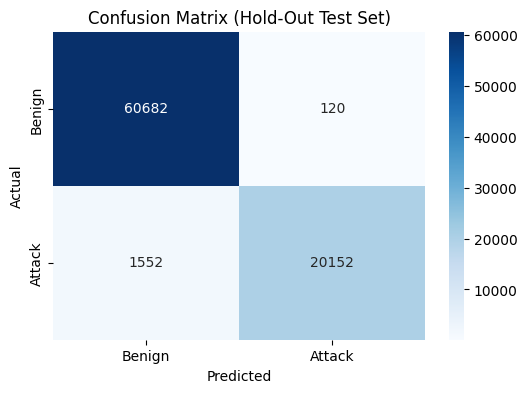

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Benign","Attack"],
            yticklabels=["Benign","Attack"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Hold-Out Test Set)")
plt.show()


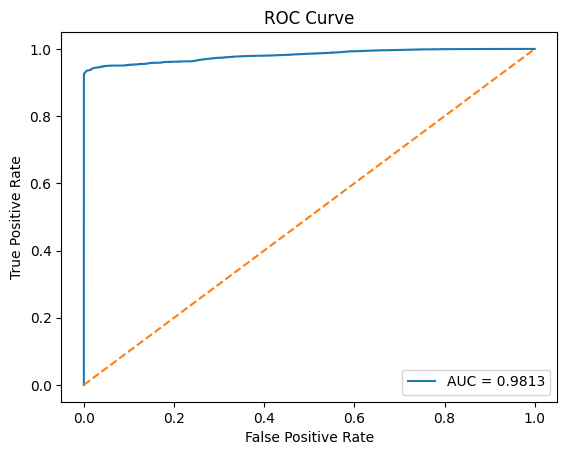

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


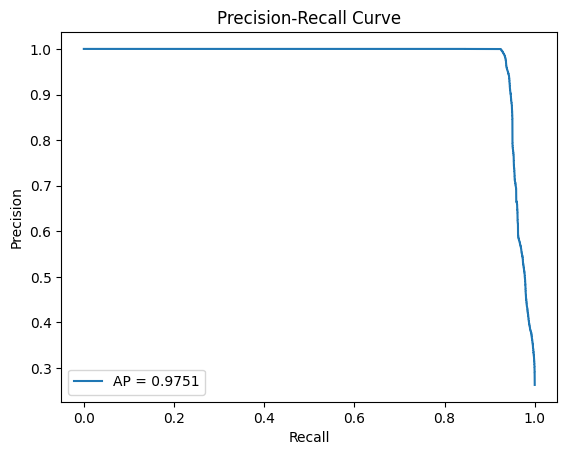

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/IDS_Research_Results"
FIG_PATH = f"{BASE_PATH}/figures"

os.makedirs(FIG_PATH, exist_ok=True)

print("Figures will be saved in:", FIG_PATH)


Figures will be saved in: /content/drive/MyDrive/IDS_Research_Results/figures


In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Benign","Attack"],
            yticklabels=["Benign","Attack"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Proposed Ensemble IDS")

plt.tight_layout()
plt.savefig(
    f"{FIG_PATH}/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("Confusion matrix saved.")


Confusion matrix saved.


In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Proposed Ensemble IDS")
plt.legend()

plt.tight_layout()
plt.savefig(
    f"{FIG_PATH}/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("ROC curve saved.")


ROC curve saved.


In [ ]:
plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Proposed Ensemble IDS")
plt.legend()

plt.tight_layout()
plt.savefig(
    f"{FIG_PATH}/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("Precision-Recall curve saved.")


Precision-Recall curve saved.
